# 02 — Grade progression under two conventions

"First at grade" is ambiguous in sport climbing, and the divergence between
its two readings is the central finding of this repo, not a caveat:

- **`as_proposed`** — the grade a route was given at its first ascent: the
  sport's contemporaneous belief about its own ceiling.
- **`as_consensus`** — the grade the route holds today after repeats:
  retrospective, and it rewrites history.

Every table, fit and estimate below is produced under both, from
`milestones.py`, which derives them from the data (the seed lists there are
reconciliation targets only). Ten milestone grades (8a+ … 9c) versus six on
the boulder side, so the fits are better constrained.

In [1]:
import numpy as np
import pandas as pd

from sportgradehistory import config
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal
from sportgradehistory.milestones import (
    breakthrough_table, load_sport, milestone_table, reconcile,
    SEED_AS_PROPOSED, SEED_AS_CONSENSUS)

sport = load_sport()   # single-pitch, deduplicated, statuses attached
BASE = french_ordinal("8a+")

tables = {}
for convention in ("as_proposed", "as_consensus"):
    t = breakthrough_table(sport, convention)
    t["year_frac"] = (t["first_ascent"].dt.year
                      + (t["first_ascent"].dt.dayofyear - 1) / 365.25)
    t["steps"] = t["grade_order"] - BASE   # 8a+ = 0, 9c = 9
    tables[convention] = t
    t.to_csv(config.PROCESSED_DIR / f"milestones_{convention}.csv", index=False)

with_disputed = breakthrough_table(sport, "as_proposed", include_disputed=True)
with_disputed.to_csv(config.PROCESSED_DIR / "milestones_with_disputed.csv",
                     index=False)

cols = ["grade", "route", "climber", "first_ascent", "date_precision", "status"]
for convention, t in tables.items():
    print(f"── {convention}")
    print(t[cols].to_string(index=False), end="\n\n")

── as_proposed
grade                          route          climber first_ascent date_precision     status
  8a+                       The Face    Jerry Moffatt   1983-01-01           year  consensus
   8b                Kanal im Rücken Wolfgang Güllich   1984-10-24            day  consensus
  8b+               Punks in the Gym Wolfgang Güllich   1985-01-01           year  consensus
   8c                     Wallstreet Wolfgang Güllich   1987-01-01           year  consensus
  8c+                         Hubble         Ben Moon   1990-06-14            day   regraded
   9a                 Action Directe Wolfgang Güllich   1991-09-14            day  consensus
  9a+                     Biographie     Chris Sharma   2001-07-18            day  consensus
   9b Ali Hulk (extension sit start)     Dani Andrada   2007-11-08            day   regraded
  9b+                         Change       Adam Ondra   2012-10-04            day  consensus
   9c                        Silence       Adam Ondra  

Unresolved orderings (year-only dates cannot be ranked against dated ones in
the same year) are carried explicitly — nothing below pretends these are
settled:

In [2]:
for convention, t in tables.items():
    amb = t[t["ordering_unresolved_with"].notna()]
    for _, r in amb.iterrows():
        print(f"{convention:<13} {r['grade']:<4} {r['route']} "
              f"({r['first_ascent_date' if 'first_ascent_date' in r else 'first_ascent']}) "
              f"~ vs ~ {r['ordering_unresolved_with']}")

as_proposed   8b   Kanal im Rücken (1984-10-24 00:00:00) ~ vs ~ Les Mains Sales (Marc Le Menestrel, 1984)
as_consensus  8b   Kanal im Rücken (1984-10-24 00:00:00) ~ vs ~ Les Mains Sales (Marc Le Menestrel, 1984)
as_consensus  9a+  Qui (1996-01-01 00:00:00) ~ vs ~ Open Air (Alexander Huber, 6th Dec 1996)


## Reconciliation against the seed lists

Reported, not adopted. Two genuine disagreements survive (the same-year ties
above are flagged, and the Realization/Biographie naming is an alias):

In [3]:
for convention, seeds in (("as_proposed", SEED_AS_PROPOSED),
                          ("as_consensus", SEED_AS_CONSENSUS)):
    rec = reconcile(milestone_table(sport, convention), seeds)
    bad = rec[~rec["agrees"]]
    print(f"── {convention}: {rec['agrees'].sum()}/{len(rec)} agree")
    if not bad.empty:
        print(bad[["grade", "seed_route", "seed_year", "found_route",
                   "found_year"]].to_string(index=False))
    print()

── as_proposed: 9/10 agree
grade seed_route  seed_year                    found_route  found_year
   9b Jumbo Love       2008 Ali Hulk (extension sit start)        2007

── as_consensus: 9/10 agree
grade seed_route  seed_year found_route  found_year
  9a+   Open Air       1996         Qui        1996



**What the disagreements are.**

- **8b, both conventions:** two routes share 1984 — *Les Mains Sales* (Le
  Menestrel, Buoux, "1984", year-only) and *Kanal im Rücken* (Güllich,
  24 Oct 1984). A year-only date parses to 1 January, so Les Mains Sales used
  to take the slot by anchoring alone. `TIE_BREAKS` in `milestones.py` now
  gives it to **Kanal im Rücken**, the route carrying a real date and the one
  both Wikipedia's milestone list and this module's seed lists name; Les Mains
  Sales stays reported in `ordering_unresolved_with`, because the ordering
  itself is still not something the data can settle. The fits below therefore
  carry 8b at 1984.81 rather than 1984.00.
- **9b, `as_proposed`:** the data genuinely disagrees with the usual telling:
  *Ali Hulk (extension sit start)* carries a recorded 9b suggestion by Dani
  Andrada dated **8 Nov 2007** — ten months before Jumbo Love (11 Sep 2008).
  The route has since settled at 9a+, which is exactly what `as_proposed`
  measures: the contemporaneous claim. Reported as found.
- **9a+, `as_consensus`:** the seed says Open Air (6 Dec 1996); the data adds
  *Qui* (Stefan Fürst, "1996", year-only, suggested 8c+/9a, now 9a+). Same
  year, unresolved ordering; either way 9a+ lands in **1996**, five years
  before Realization.

**Wikipedia cross-check** (List of first ascents (sport climbing); List of
grade milestones in rock climbing, both read 2026-09-09): every consensus
milestone in the seed list matches Wikipedia; Wikipedia dates Liquid Ambar
"May 1990" where the site says 30 Mar 1990 (both precede Hubble's 14 Jun);
Wikipedia carries Open Air's 9a+ as disputed (one repeat, holds broken) and
Punks in the Gym as the benchmark 8b+ — no 8c consensus. Neither Wikipedia
list mentions Akira or Chilam Balam at all.

## The divergence, quantified

Which grades changed hands between conventions, and by how many years each
milestone moves:

In [4]:
p, c = tables["as_proposed"].set_index("grade"), tables["as_consensus"].set_index("grade")
div = pd.DataFrame({
    "proposed_route": p["route"], "proposed_year": p["first_ascent"].dt.year,
    "consensus_route": c["route"], "consensus_year": c["first_ascent"].dt.year,
})
div["changed_hands"] = div["proposed_route"] != div["consensus_route"]
div["moves_years"] = div["proposed_year"] - div["consensus_year"]
print(div.to_string())
print(f"\n{div['changed_hands'].sum()} of {len(div)} milestone grades change hands "
      "between conventions")

                       proposed_route  proposed_year   consensus_route  consensus_year  changed_hands  moves_years
grade                                                                                                             
8a+                          The Face           1983          The Face            1983          False            0
8b                    Kanal im Rücken           1984   Kanal im Rücken            1984          False            0
8b+                  Punks in the Gym           1985  Punks in the Gym            1985          False            0
8c                         Wallstreet           1987        Wallstreet            1987          False            0
8c+                            Hubble           1990      Liquid Ambar            1990           True            0
9a                     Action Directe           1991            Hubble            1990           True            1
9a+                        Biographie           2001               Qui          

In [5]:
# How many milestone routes have moved grade since their FA?
ids = set(p["climb_id"]) | set(c["climb_id"])
milestone_rows = sport[sport["climb_id"].isin(ids)]
moved = milestone_rows[milestone_rows["status"] == "regraded"]
print(f"{len(moved)} of the {len(milestone_rows)} routes appearing in either "
      "milestone table have moved off the FA suggestion:")
print(moved[["climb_name", "first_suggested_grade", "grade_clean",
             "first_ascent_year"]].to_string(index=False))
print("\n(regraded_routes.csv holds all 87 such sport routes; the suggestion "
      "field exists on only 254 of 1,978 sport rows, so this undercounts)")

4 of the 13 routes appearing in either milestone table have moved off the FA suggestion:
                    climb_name first_suggested_grade grade_clean  first_ascent_year
                        Hubble                   8c+          9a               1990
                  Liquid Ambar                    8c         8c+               1990
Ali Hulk (extension sit start)                    9b         9a+               2007
                           Qui                8c+/9a         9a+               1996

(regraded_routes.csv holds all 87 such sport routes; the suggestion field exists on only 254 of 1,978 sport rows, so this undercounts)


## Putting a line through the milestones

The obvious thing to do with ten dated points is fit a line to them. Two
directions are possible, and only one is useful: `grade ~ time` answers "how
hard was the sport in year X", while the inverse, `time ~ grade`, answers "what
year does grade X arrive" — which is the question anyone actually asks. Every
estimate below is the inverse one, so a prediction comes out as a date.

The three year-only points (The Face 1983, Punks in the Gym 1985, Wallstreet
1987) enter at 1 January of their year, which can shift a fit by at most a year.

One distortion has to be stated before any number is read. Under
`as_consensus`, **8c+ and 9a fall within eleven weeks of each other in 1990**
(Liquid Ambar 30 Mar, Hubble 14 Jun). Two points that are nearly on top of each
other in time but a full grade apart will pull any line steep and make the sport
look faster than it was. The numbers below are reported *with that said*, not as
clean summaries.

In [6]:
def fits(t):
    x, y = t["year_frac"].to_numpy(), t["steps"].to_numpy()
    g_slope, g_int = np.polyfit(x, y, 1)            # grade ~ time
    t_slope, t_int = np.polyfit(y, x, 1)            # time ~ grade (the inverse)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    return g_slope, g_int, t_slope, t_int, r2

print(f"{'convention':<14} {'steps/decade':>12} {'years/step':>11} {'R²':>6} {'9c+ (inverse fit)':>18}")
predictions = {}
for convention, t in tables.items():
    g_slope, g_int, t_slope, t_int, r2 = fits(t)
    year_9cplus = t_slope * 10 + t_int              # 9c+ is 10 steps above 8a+
    predictions[convention] = (t_slope, t_int, year_9cplus)
    print(f"{convention:<14} {g_slope*10:>12.2f} {t_slope:>11.2f} {r2:>6.3f} "
          f"{year_9cplus:>18.1f}")

convention     steps/decade  years/step     R²  9c+ (inverse fit)
as_proposed            2.27        4.04  0.919             2018.4
as_consensus           2.22        3.96  0.880             2017.3


Read those two dates carefully, because they are the model failing in public
rather than a forecast. The straight line puts 9c+ at **2018.4** (`as_proposed`)
or **2017.3** (`as_consensus`) — both already in the past by the time of the
scrape.

The reason is visible in the ladder itself: the fit is dominated by the
1983–1991 sprint, five grades in eight years, and the sport has been slowing
down ever since. The R² looks respectable only because those early points line
up well; it measures how tidily the line passes through the history, not whether
it can predict anything. Extrapolated forward, the same line said 9c would land
around 2013 and 9c+ around 2017. Neither happened on time.

The two conventions still tell different stories *within* that failure. The
consensus reading is steeper — the 1990 twins and the 1996 9a+ compress the
middle of the ladder — so its verdict on 9c+ is a year harsher. Same routes,
different history, different extrapolation, purely from the definition of
"first".

In [7]:
# The 2017-to-now gap.
import datetime as dt
now = dt.date(2026, 9, 9)          # the scrape date, not "today"
silence = tables["as_proposed"].iloc[-1]
gap = (pd.Timestamp(now) - silence["first_ascent"]).days / 365.25
print(f"Silence (9c) FA: {silence['first_ascent'].date()}  ->  {gap:.1f} years "
      "without a new top grade\n")

for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna()
    longest = iv.max()
    which = t.iloc[iv.idxmax()]
    silence_frac = t["year_frac"].iloc[-1]
    overtakes = silence_frac + longest
    verdict = ("ALREADY the longest" if gap > longest else
               f"becomes the longest in {overtakes:.1f}")
    print(f"{convention:<14} longest completed interval: {longest:.1f}y "
          f"(into {which['grade']}, {which['route']}, "
          f"{which['first_ascent'].year}) -> current stall {verdict}")

Silence (9c) FA: 2017-09-03  ->  9.0 years without a new top grade

as_proposed    longest completed interval: 9.8y (into 9a+, Biographie, 2001) -> current stall becomes the longest in 2027.5
as_consensus   longest completed interval: 12.7y (into 9b, Jumbo Love, 2008) -> current stall becomes the longest in 2030.4


**Is 2017–now the longest stall in the sport's history?** Not yet — under
either convention, which is worth stating against the popular framing:

- **`as_proposed`:** the longest completed wait is Action Directe →
  Biographie (9a → 9a+), **9.8 years**. The current stall (9.0y) overtakes it
  in **mid-2027**.
- **`as_consensus`:** consensus rewrites 9a+ back to 1996, making 9a+ → 9b a
  **12.7-year** wait; the current stall overtakes that only around
  **mid-2030**.

So the stall is long, but the sport has waited longer — once before under one
reading, once under the other. What makes 2017–now remarkable is not its
length alone but that it follows two *fast* intervals (9b→9b+ and 9b+→9c,
both 4.9y), so the deceleration is abrupt rather than gradual.

What did the linear model expect? Fitting `time ~ grade` on the pre-Silence
points (through 9b+) and asking for the 9c date:

In [8]:
for convention, t in tables.items():
    pre = t[t["grade"] != "9c"]
    slope, intercept = np.polyfit(pre["steps"], pre["year_frac"], 1)
    predicted_9c = slope * 9 + intercept
    predicted_9cp = slope * 10 + intercept
    print(f"{convention:<14} pre-2017 fit expected 9c ≈ {predicted_9c:.0f} "
          f"(actual 2017.7), and 9c+ ≈ {predicted_9cp:.0f}")

as_proposed    pre-2017 fit expected 9c ≈ 2013 (actual 2017.7), and 9c+ ≈ 2016
as_consensus   pre-2017 fit expected 9c ≈ 2011 (actual 2017.7), and 9c+ ≈ 2015


The pre-Silence fits expected 9c around 2011–2013; Ondra delivered it in
2017, four to six years *behind* the linear schedule — and those same fits
expected 9c+ around 2015–2016, now ten to eleven years overdue. The linear
model has been running behind reality since roughly Realization, in the same
direction every time. That is what a decelerating process does to a straight
line, and it is why the estimate below leans on the intervals themselves
rather than the global fit.

A more honest 9c+ estimate, three ways:

In [9]:
# Three models that respect the deceleration, per convention.
for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna().to_numpy()
    last = t["year_frac"].iloc[-1]
    # (a) repeat the last completed interval
    a = last + iv[-1]
    # (b) mean of the last three intervals
    b = last + iv[-3:].mean()
    # (c) extrapolate the widening trend: fit interval length on step index
    slope, intercept = np.polyfit(range(len(iv)), iv, 1)
    c_est = last + (slope * len(iv) + intercept)
    print(f"{convention:<14} (a) repeat-last: {a:.0f}   "
          f"(b) mean-of-3: {b:.0f}   (c) widening-trend: {c_est:.0f}")

as_proposed    (a) repeat-last: 2023   (b) mean-of-3: 2023   (c) widening-trend: 2025
as_consensus   (a) repeat-last: 2023   (b) mean-of-3: 2025   (c) widening-trend: 2026


Even the models built for a slowing sport put 9c+ between **2022 and 2026**
— at or before the scrape date. Every simple reading of this history says the
next grade is overdue; the one that says it least (the widening-trend model)
says it is due about now. Either 9c+ is imminent, or the sport has entered a
regime its own history cannot yet describe. State that as the finding rather
than any single year.

## Intervals between milestones — is the ladder slowing?

In [10]:
for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna().round(1)
    labels = [f"{a}->{b}" for a, b in zip(t['grade'][:-1], t['grade'][1:])]
    series = pd.Series(iv.values, index=labels)
    print(f"── {convention}: median {series.median():.1f}y")
    print(series.to_string(), end="\n\n")

# Widening? Rank-correlate interval length with order.
from scipy.stats import spearmanr
for convention, t in tables.items():
    iv = t["year_frac"].diff().dropna()
    rho, pval = spearmanr(range(len(iv)), iv)
    print(f"{convention:<14} Spearman rho={rho:+.2f} (p={pval:.2f}) "
          "-> " + ("intervals lengthening" if rho > 0.3 else
                   "no clear widening trend"))

── as_proposed: median 3.4y
8a+->8b    1.8
8b->8b+    0.2
8b+->8c    2.0
8c->8c+    3.4
8c+->9a    1.3
9a->9a+    9.8
9a+->9b    6.3
9b->9b+    4.9
9b+->9c    4.9

── as_consensus: median 3.2y
8a+->8b     1.8
8b->8b+     0.2
8b+->8c     2.0
8c->8c+     3.2
8c+->9a     0.2
9a->9a+     5.6
9a+->9b    12.7
9b->9b+     4.1
9b+->9c     4.9



as_proposed    Spearman rho=+0.72 (p=0.03) -> intervals lengthening
as_consensus   Spearman rho=+0.73 (p=0.02) -> intervals lengthening


## Polynomials, shown only to be distrusted

Higher-order fits track ten points beautifully and then extrapolate into
nonsense — the cubic sends the ceiling vertical or backwards within a decade
of the data's edge. They are drawn here so the reader can watch them fail;
the linear fit is the honest one, exactly as in the boulder repo.

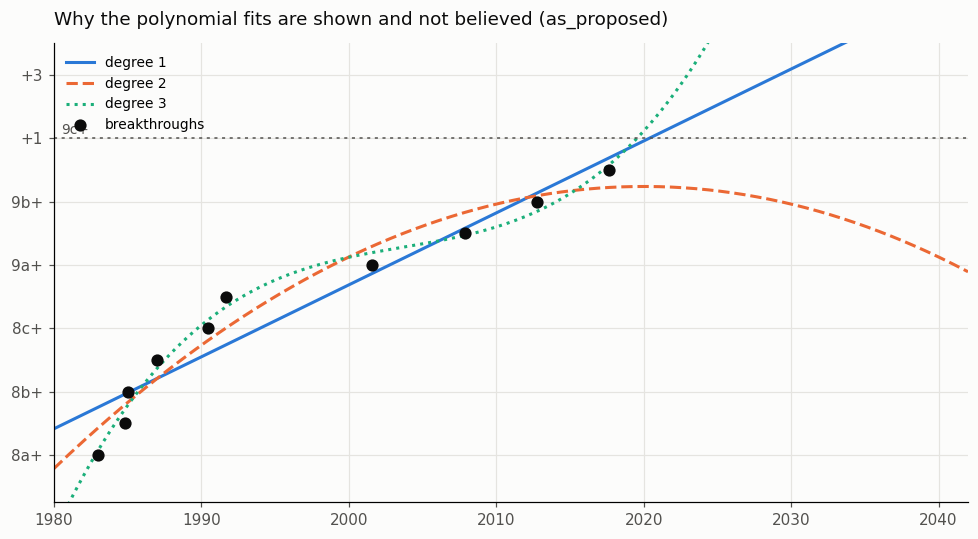

degree 1: crosses 9c+ ≈ 2020, predicts +14.5 steps above 8a+ by 2040
degree 2: crosses 9c+ never (by 2042), predicts +6.3 steps above 8a+ by 2040
degree 3: crosses 9c+ ≈ 2020, predicts +35.5 steps above 8a+ by 2040


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
t = tables["as_proposed"]
x, y = t["year_frac"].to_numpy(), t["steps"].to_numpy()
grid_x = np.linspace(1980, 2042, 300)

for deg, color, style in ((1, "#2a78d6", "-"), (2, "#eb6834", "--"),
                          (3, "#1baf7a", ":")):
    coeffs = np.polyfit(x, y, deg)
    ax.plot(grid_x, np.polyval(coeffs, grid_x), style, color=color, lw=2,
            label=f"degree {deg}")
ax.plot(x, y, "o", color="#0b0b0b", ms=7, zorder=5, label="breakthroughs")

ax.axhline(10, color="#52514e", lw=1, ls=(0, (2, 3)))
ax.text(1980.5, 10.15, "9c+", fontsize=9, color="#52514e")
ax.set_ylim(-1.5, 13); ax.set_xlim(1980, 2042)
ax.set_yticks(range(0, 13, 2))
ax.set_yticklabels([FRENCH_SCALE[BASE + s] if BASE + s < len(FRENCH_SCALE)
                    else f"+{s-9}" for s in range(0, 13, 2)])
ax.grid(color="#e5e4e0", lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Why the polynomial fits are shown and not believed (as_proposed)",
             color="#0b0b0b", fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

future = grid_x[grid_x >= 2018]
for deg in (1, 2, 3):
    coeffs = np.polyfit(x, y, deg)
    above = np.polyval(coeffs, future) >= 10
    crossing = f"≈ {future[np.argmax(above)]:.0f}" if above.any() else "never (by 2042)"
    val_2040 = np.polyval(coeffs, 2040)
    print(f"degree {deg}: crosses 9c+ {crossing}, "
          f"predicts {val_2040:+.1f} steps above 8a+ by 2040")

## First-repeat lag — what this data cannot say

Sport confirmation lags are long and are part of the story, but **this scrape
kept only the first ascent row per climb**, not the full ascent list, so
"years until first repeat" is not computable from `data/processed/`. What it
does support is the weaker proxy below: how much of each top grade is still
unrepeated today — which is itself a confirmation-lag statement (Silence has
waited nine years).

In [12]:
top = sport[sport["grade_order"] >= french_ordinal("9a")]
share = (top.assign(unrepeated=top["num_ascents"] <= 1)
         .groupby("grade_clean", sort=False)["unrepeated"]
         .agg(["sum", "count"]))
share = share.reindex(sorted(share.index, key=french_ordinal))
share["pct"] = (100 * share["sum"] / share["count"]).round(0).astype(int)
print("unrepeated share by grade (proxy for confirmation lag):")
print(share.to_string())

unrepeated share by grade (proxy for confirmation lag):
             sum  count  pct
grade_clean                 
9a           113    318   36
9a+           74    173   43
9b            49     76   64
9b+            6     11   55
9c             5      5  100


## The picture

One chart, one axis: the ceiling over time under both conventions, with the
disputed claims shown as open markers — visible, never merged into a line.

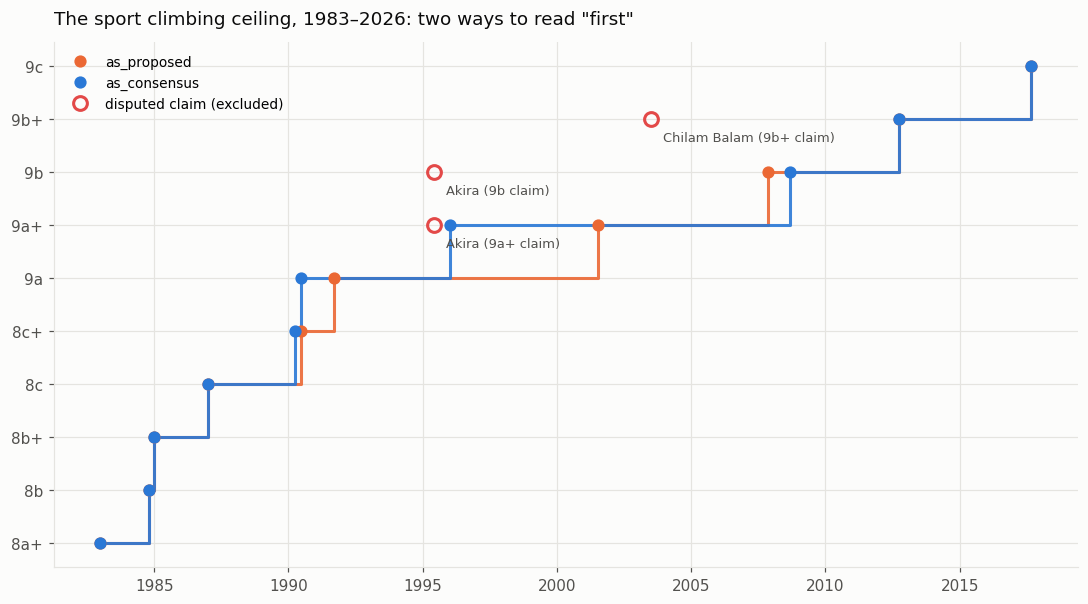

In [13]:
import matplotlib.dates as mdates

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"

fig, ax = plt.subplots(figsize=(10, 5.6), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for (convention, t), color in zip(tables.items(), (ORANGE, BLUE)):
    ax.step(t["first_ascent"], t["steps"], where="post", color=color, lw=2,
            alpha=.9, zorder=2)
    ax.plot(t["first_ascent"], t["steps"], "o", color=color, ms=7, zorder=3,
            label=convention)

disp = with_disputed[with_disputed["status"] == "disputed"]
ax.plot(disp["first_ascent"], disp["grade_order"] - BASE, "o", ms=9, mfc="none",
        mec=RED, mew=2, zorder=4, label="disputed claim (excluded)")
for _, r in disp.iterrows():
    ax.annotate(f"{r['route']} ({r['grade']} claim)",
                (r["first_ascent"], r["grade_order"] - BASE),
                xytext=(8, -14), textcoords="offset points",
                fontsize=8.5, color=MUTED)

ax.set_yticks(range(10))
ax.set_yticklabels(FRENCH_SCALE[BASE:BASE + 10], color=INK)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.grid(color=GRID, lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("The sport climbing ceiling, 1983–2026: two ways to read \"first\"",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

The two histories agree at the ends and disagree in the middle: consensus
pulls 8c+→9a into one 1990 spring and drags 9a+ five years earlier, while the
proposed reading keeps the ladder evenly spaced through the 1990s. Akira and
Chilam Balam, if accepted, would each pre-empt a milestone by a decade — which
is exactly why they are drawn as open circles and kept out of both lines.
Notebook 04 renders the poster versions of this figure into `figures/`.

## The consensus ladder on its own

Everything above carries both conventions side by side, because the divergence
between them is the finding. The rest of this notebook drops `as_proposed` and
works only with **`as_consensus`** — the ten routes that hold each grade
*today*, after repeats. One line, one axis, no overlay:

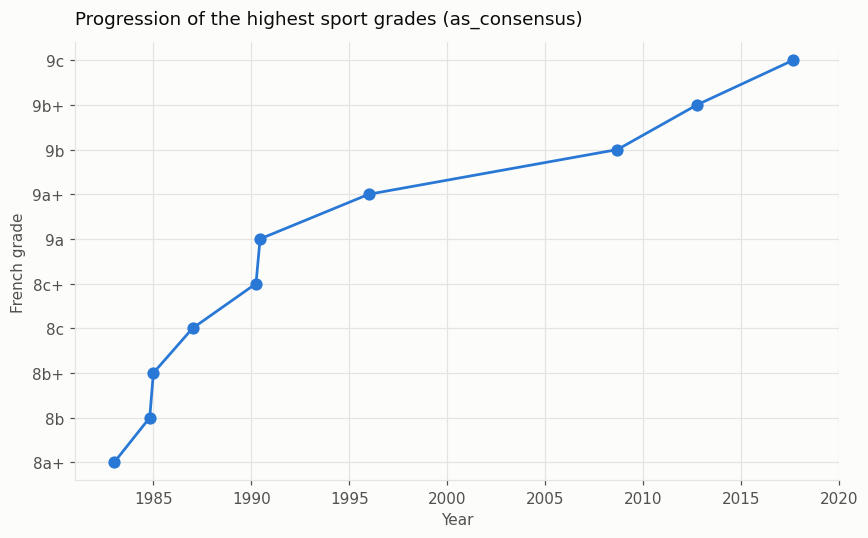

grade            route          climber first_ascent
  8a+         The Face    Jerry Moffatt   1983-01-01
   8b  Kanal im Rücken Wolfgang Güllich   1984-10-24
  8b+ Punks in the Gym Wolfgang Güllich   1985-01-01
   8c       Wallstreet Wolfgang Güllich   1987-01-01
  8c+     Liquid Ambar    Jerry Moffatt   1990-03-30
   9a           Hubble         Ben Moon   1990-06-14
  9a+              Qui     Stefan Fürst   1996-01-01
   9b       Jumbo Love     Chris Sharma   2008-09-11
  9b+           Change       Adam Ondra   2012-10-04
   9c          Silence       Adam Ondra   2017-09-03


In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

PAPER, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
LADDER = list(FRENCH_SCALE[BASE:BASE + 10]) + ["9c+"]   # 9c+ is past the scale

con = tables["as_consensus"]

fig, ax = plt.subplots(figsize=(8, 5), dpi=110, facecolor=PAPER)
ax.set_facecolor(PAPER)
ax.plot(con["year_frac"], con["steps"], "-o", color="#2a78d6", lw=1.8, ms=7,
        zorder=3, clip_on=False)

ax.set_yticks(range(10))
ax.set_yticklabels(LADDER[:10])
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.set_xlim(1981, 2020); ax.set_ylim(-0.4, 9.4)
ax.set_xlabel("Year", color=MUTED); ax.set_ylabel("French grade", color=MUTED)
ax.grid(color=GRID, lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.set_title("Progression of the highest sport grades (as_consensus)",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

print(con[["grade", "route", "climber", "first_ascent"]].to_string(index=False))

The near-vertical step in 1990 is the consensus reading's fingerprint: Liquid
Ambar (8c+, 30 Mar) and Hubble (9a, 14 Jun) eleven weeks apart. After 1996 the
line flattens hard — 9a+ to 9b alone takes 12.7 years.

## Six curve shapes against one held-out grade

The fits earlier in this notebook use all ten milestones and then extrapolate,
which gives no way to tell a good shape from a bad one. This does it the other
way round: **fit on 8a+ → 9b+ only (nine points), then predict 9c and check the
answer against Silence.** The models never see 2017.

Orientation is the inverse fit — grade on x, time on y — so a "prediction" is a
date, which is the quantity anyone actually wants. Time is measured in months
since The Face (1 Jan 1983, year-only precision, as everywhere above).

- **Poly 1–4** — least squares on nine points, so degree 4 is a genuine fit
  (five parameters), not interpolation.
- **Exponential** — `a·exp(b·g) + k`, seeded from a log-space fit so the
  optimiser starts somewhere sane.
- **Logarithmic** — `a·ln(g + 1) + b`, the shifted form, since grade 0 is in
  the data.

Scored by how far each lands from the real 9c date; the closest one then gets
asked about 9c+.

In [15]:
from scipy.optimize import curve_fit

ORIGIN = con["year_frac"].iloc[0]                    # The Face, 1983.0
con = con.assign(months=(con["year_frac"] - ORIGIN) * 12)

train = con[con["steps"] <= 8]                       # 8a+ ... 9b+
x, y = train["steps"].to_numpy(float), train["months"].to_numpy(float)
actual_9c = float(con.loc[con["steps"] == 9, "months"].iloc[0])


def exp_model(g, a, b, k):
    return a * np.exp(b * g) + k


def log_model(g, a, b):
    return a * np.log(g + 1) + b


models = {}
for deg in (1, 2, 3, 4):
    models[f"Poly {deg}"] = (lambda g, k=np.polyfit(x, y, deg):
                             np.polyval(k, g))

log_b, log_a = np.polyfit(x, np.log(y + 1.0), 1)     # seed for the optimiser
p_exp, _ = curve_fit(exp_model, x, y, p0=(np.exp(log_a), log_b, -1.0),
                     maxfev=200000)
models["Exponential"] = lambda g, p=p_exp: exp_model(g, *p)
p_log, _ = curve_fit(log_model, x, y, p0=(100.0, 0.0), maxfev=200000)
models["Logarithmic"] = lambda g, p=p_log: log_model(g, *p)

rows = []
for name, f in models.items():
    pred = float(f(9.0))
    rows.append({
        "model": name,
        "9c predicted": ORIGIN + pred / 12,
        "miss (years)": (pred - actual_9c) / 12,
        "abs_miss": abs(pred - actual_9c) / 12,
        "train RMSE (months)": float(np.sqrt(np.mean((y - f(x)) ** 2))),
        "9c+ implied": ORIGIN + float(f(10.0)) / 12,
    })
scores = (pd.DataFrame(rows).sort_values("abs_miss")
          .reset_index(drop=True))

print(f"actual 9c: Silence, {ORIGIN + actual_9c / 12:.2f}\n")
print(scores.drop(columns="abs_miss").round(2).to_string(index=False))

actual 9c: Silence, 2017.67

      model  9c predicted  miss (years)  train RMSE (months)  9c+ implied
     Poly 4       2019.92          2.25                18.98      2022.05
     Poly 2       2022.35          4.68                22.82      2032.70
     Poly 1       2011.12         -6.55                48.70      2014.72
     Poly 3       2026.54          8.87                20.71      2041.91
Exponential       2028.11         10.44                21.67      2047.66
Logarithmic       2003.47        -14.20                75.14      2004.59


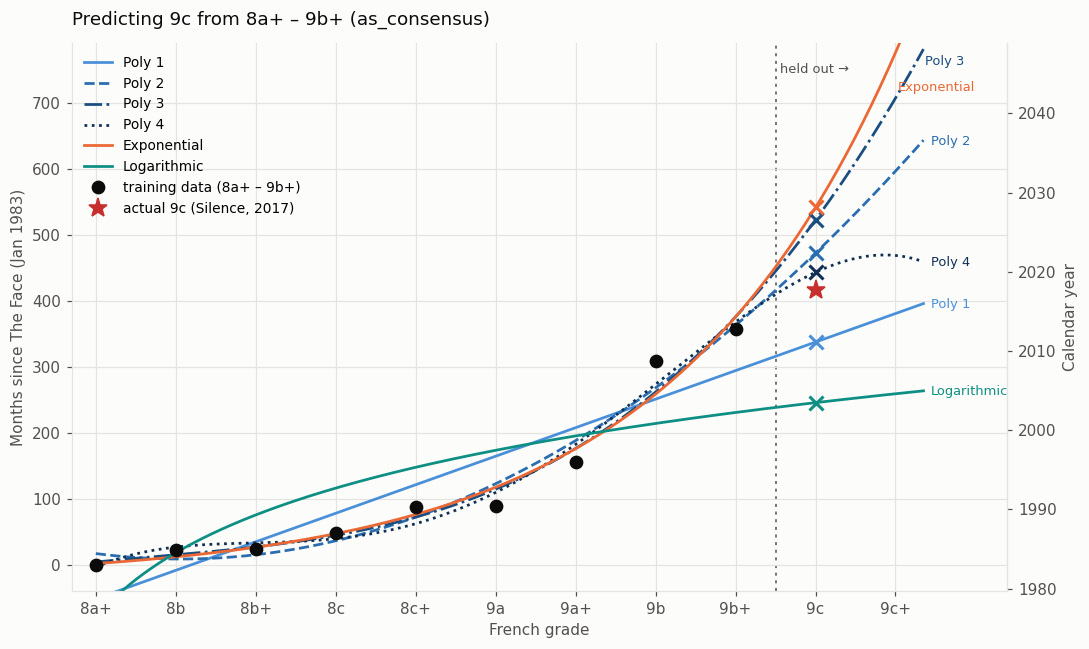

In [16]:
STYLE = {                       # poly degree is ordinal -> one ramp + dashes;
    "Poly 1":      ("#4a90d9", "-"),      # exp and log get their own hues
    "Poly 2":      ("#2a6db0", "--"),
    "Poly 3":      ("#1b4e80", "-."),
    "Poly 4":      ("#0f3054", ":"),
    "Exponential": ("#eb6834", "-"),
    "Logarithmic": ("#0e8f83", "-"),
}
Y_TOP, GAP = 790, 34            # GAP: minimum vertical room between labels

fig, ax = plt.subplots(figsize=(10, 6), dpi=110, facecolor=PAPER)
ax.set_facecolor(PAPER)
grid_g = np.linspace(0, 10.35, 400)

placed = []                     # label anchors already used, to stagger off
for name, f in models.items():
    color, ls = STYLE[name]
    curve = f(grid_g)
    ax.plot(grid_g, curve, ls, color=color, lw=1.8, label=name, zorder=2)
    ax.plot([9], [f(9.0)], "x", color=color, ms=9, mew=2, zorder=4)

    visible = np.flatnonzero(curve <= Y_TOP - 25)   # label where still in frame
    if not visible.size:
        continue
    j = visible[-1]
    ly = curve[j]
    while any(abs(ly - prev) < GAP for prev in placed):
        ly -= GAP                                   # curves that exit together
    placed.append(ly)
    ax.annotate(name, (grid_g[j], ly), xytext=(5, -3),
                textcoords="offset points", fontsize=8.5, color=color)

ax.plot(x, y, "o", color=INK, ms=8, zorder=5, label="training data (8a+ – 9b+)")
ax.plot([9], [actual_9c], "*", color="#c62f2c", ms=13, zorder=6,
        label="actual 9c (Silence, 2017)")

ax.axvline(8.5, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
ax.text(8.56, Y_TOP - 45, "held out →", fontsize=8.5, color=MUTED)

ax.set_xticks(range(11)); ax.set_xticklabels(LADDER)
ax.set_xlim(-0.3, 11.4); ax.set_ylim(-40, Y_TOP)
ax.set_xlabel("French grade", color=MUTED)
ax.set_ylabel("Months since The Face (Jan 1983)", color=MUTED)

sec = ax.secondary_yaxis("right", functions=(lambda m: ORIGIN + m / 12,
                                             lambda yr: (yr - ORIGIN) * 12))
sec.set_ylabel("Calendar year", color=MUTED)
sec.tick_params(colors=MUTED); sec.spines["right"].set_color(GRID)

ax.grid(color=GRID, lw=.8, zorder=0)
ax.spines["top"].set_visible(False)
for side in ("left", "bottom", "right"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Predicting 9c from 8a+ – 9b+ (as_consensus)",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

**Nothing here gets within two years of Silence.**

The sign pattern is the readable part. The two shapes that land *early* — the
straight line (−6.6 years) and the logarithm (−14.2) — are the two that cannot
accelerate. The two that overshoot by a decade — the cubic (+8.9) and the
exponential (+10.4) — are the two that cannot stop. The real ladder steepens
through the 1990s and then levels off again, so the shapes that can bend twice
come closest: the quartic (+2.3) and the quadratic (+4.7).

**So the quartic wins — and that is the trap.** One held-out point gives one
number per shape and no way to tell skill from luck. The next section puts the
same six shapes through five separate tests instead of one, and the shape that
won here finishes last there.

## A better test: make each method predict grades it never saw

The section above ranked six shapes on a single number — how far each landed
from Silence. That is one guess per shape with no track record behind it, and it
is the weakest evidence in this notebook. Three ways to do better, in increasing
order of how much they resemble the actual question:

- **Charge each curve for its own flexibility.** A curve with more knobs will
  always hug the points it was drawn through more tightly, so "fits best" rewards
  complexity rather than truth. The standard corrections (AICc, BIC, adjusted R²)
  subtract a penalty for every extra knob.
- **Hide one milestone at a time and predict it from the other nine.** Ten tests
  instead of one — but it mostly asks each shape to fill in a gap it is already
  surrounded by, which is easier than what we want.
- **Re-run history.** Train on the first *j* milestones only, predict the next
  one, and repeat for j = 5 … 9. Five tests, each a genuine step past the end of
  what the method was allowed to see — exactly the shape of the 9c+ question.
  (The statistical name is rolling-origin validation.) **This is the one worth
  deciding on.**

The same test also scores the three **interval models** from earlier in this
notebook — repeat the last gap, average the last three, extend the widening
trend. They are not curves through the points, so there is nothing to fit and
nothing to penalise, but they do predict the next date, which puts them on equal
terms with the curves for the first time. That comparison changes the answer.

In [17]:
# Six curve shapes and three interval models, scored on the same folds.
GV = con["steps"].to_numpy(float)          # 0 (8a+) ... 9 (9c)
YV = con["year_frac"].to_numpy(float)
MV = (YV - ORIGIN) * 12                    # months since The Face
NV = len(GV)
SHAPES = ["Poly 1", "Poly 2", "Poly 3", "Poly 4", "Exponential", "Logarithmic"]
INTERVALS = ["Repeat last interval", "Mean of last 3", "Widening trend"]
N_PAR = {"Poly 1": 2, "Poly 2": 3, "Poly 3": 4, "Poly 4": 5,
         "Exponential": 3, "Logarithmic": 2}


# fit `name` to the milestones given, and predict the date at `target` steps
def fit_on(name, gs, ms, ys, target):
    if name.startswith("Poly"):
        deg = int(name[-1])
        if len(gs) < deg + 1:
            return np.nan                  # underdetermined, not estimable
        return ORIGIN + float(np.polyval(np.polyfit(gs, ms, deg), target)) / 12
    if name == "Exponential":
        b, a = np.polyfit(gs, np.log(ms + 1.0), 1)
        p, _ = curve_fit(exp_model, gs, ms, p0=(np.exp(a), b, -1.0), maxfev=200000)
        return ORIGIN + float(exp_model(target, *p)) / 12
    if name == "Logarithmic":
        p, _ = curve_fit(log_model, gs, ms, p0=(100.0, 0.0), maxfev=200000)
        return ORIGIN + float(log_model(target, *p)) / 12
    iv, last, ahead = np.diff(ys), ys[-1], target - gs[-1]
    if name == "Repeat last interval":
        return last + iv[-1] * ahead
    if name == "Mean of last 3":
        return last + iv[-3:].mean() * ahead
    if name == "Widening trend":
        s, i = np.polyfit(range(len(iv)), iv, 1)
        return last + float(sum(s * (len(iv) + q) + i
                                for q in range(int(round(ahead)))))


def trained_on_first(name, j, target):
    return fit_on(name, GV[:j], MV[:j], YV[:j], target)


insample = []
for name in SHAPES:
    res_mo = (np.array([fit_on(name, GV, MV, YV, g) for g in GV]) - YV) * 12
    rss = float(res_mo @ res_mo)
    k = N_PAR[name] + 1                    # +1 for the variance term
    aic = NV * np.log(rss / NV) + 2 * k
    if NV - k - 1 > 0:
        aicc = aic + (2 * k * (k + 1)) / (NV - k - 1)
    else:
        aicc = np.inf                      # too few points to correct
    tss = float((MV - MV.mean()) @ (MV - MV.mean()))
    r2 = 1 - rss / tss
    loo = []                               # leave-one-out: interior points too
    for i in range(NV):
        keep = np.ones(NV, bool)
        keep[i] = False
        loo.append(fit_on(name, GV[keep], MV[keep], YV[keep], GV[i]) - YV[i])
    insample.append({"shape": name, "params": N_PAR[name],
                     "RMSE (mo)": np.sqrt(rss / NV),
                     "adj R2": 1 - (1 - r2) * (NV - 1) / (NV - N_PAR[name]),
                     "AICc": aicc,
                     "BIC": NV * np.log(rss / NV) + k * np.log(NV),
                     "LOOCV (y)": float(np.sqrt(np.mean(np.square(loo))))})

INSAMPLE = pd.DataFrame(insample).set_index("shape")

# Scoring a curve on the points it was drawn through rewards flexibility, so
# these criteria are reported as a single verdict rather than a table: the
# question is only whether they agree with each other, and they do not.
picks = {"lowest error": INSAMPLE["RMSE (mo)"].idxmin(),
         "adjusted R2": INSAMPLE["adj R2"].idxmax(),
         "AICc": INSAMPLE["AICc"].idxmin(),
         "BIC": INSAMPLE["BIC"].idxmin(),
         "leave-one-out": INSAMPLE["LOOCV (y)"].idxmin()}
print("HOW WELL EACH CURVE FITS THE TEN POINTS IT WAS DRAWN THROUGH.")
print("Five ways to score that, and they do not agree:\n")
for crit, shape in picks.items():
    print(f"  {crit:<16} picks {shape}")
print(f"\n  -> {len(set(picks.values()))} different answers from 5 criteria. "
      "Criteria that reward\n     flexibility pick the wiggliest shape; "
      "criteria that charge for it pick a\n     simpler one. None of them is "
      "a test of prediction. (Full table in INSAMPLE.)")

roll = []
for name in SHAPES + INTERVALS:
    e = np.array([trained_on_first(name, j, GV[j]) - YV[j] for j in range(5, NV)])
    roll.append({"method": name, "RMSE (y)": np.sqrt(np.nanmean(e ** 2)),
                 "MAE (y)": np.nanmean(np.abs(e)), "bias (y)": np.nanmean(e),
                 "worst (y)": np.nanmax(np.abs(e)),
                 "9c+": fit_on(name, GV, MV, YV, 10.0), "errors": e})

ens = np.array([np.mean([trained_on_first(m, j, GV[j]) for m in INTERVALS]) - YV[j]
                for j in range(5, NV)])    # does averaging them help?
roll.append({"method": "Ensemble of the 3 interval models",
             "RMSE (y)": np.sqrt(np.mean(ens ** 2)), "MAE (y)": np.mean(np.abs(ens)),
             "bias (y)": np.mean(ens), "worst (y)": np.max(np.abs(ens)),
             "9c+": float(np.mean([fit_on(m, GV, MV, YV, 10.0) for m in INTERVALS])),
             "errors": ens})

ROLL = pd.DataFrame(roll).sort_values("RMSE (y)").reset_index(drop=True)
print("\n\nROLLING-ORIGIN: train on the first j milestones, predict the next,")
print("for j = 5 ... 9. Every fold is an extrapolation, as 9c+ is.\n")
print(ROLL.drop(columns="errors").round(2).to_string(index=False))
print("\nper-fold error, + = predicted late (predicting 9a, 9a+, 9b, 9b+, 9c):")
for _, r in ROLL.iterrows():
    print(f"  {r['method']:<34} "
          + "  ".join(f"{v:+6.1f}" for v in r["errors"]))

BEST = ROLL.iloc[0]
print(f"\nselected on validation: {BEST['method']} -> 9c+ {BEST['9c+']:.1f} "
      f"(+/-1 RMSE: {BEST['9c+'] - BEST['RMSE (y)']:.1f} to "
      f"{BEST['9c+'] + BEST['RMSE (y)']:.1f})")

HOW WELL EACH CURVE FITS THE TEN POINTS IT WAS DRAWN THROUGH.
Five ways to score that, and they do not agree:

  lowest error     picks Poly 4
  adjusted R2      picks Poly 4
  AICc             picks Poly 2
  BIC              picks Poly 4
  leave-one-out    picks Poly 2

  -> 2 different answers from 5 criteria. Criteria that reward
     flexibility pick the wiggliest shape; criteria that charge for it pick a
     simpler one. None of them is a test of prediction. (Full table in INSAMPLE.)


ROLLING-ORIGIN: train on the first j milestones, predict the next,
for j = 5 ... 9. Every fold is an extrapolation, as 9c+ is.

                           method  RMSE (y)  MAE (y)  bias (y)  worst (y)     9c+
                   Mean of last 3      4.92     3.93     -1.44       9.70 2024.89
Ensemble of the 3 interval models      5.10     4.51     -0.63       8.46 2024.33
                           Poly 2      5.19     4.33     -0.73       9.65 2028.48
                   Widening trend      5.33    

**The single held-out point crowned the worst forecaster in the set.** Poly 4
won that contest (+2.3 years on 9c) and finishes **last** across five tests,
with a typical miss of 12.0 years. Its five errors were −0.3, −16.6, −4.4,
**+20.6**, +2.3 — the 9c hit was the last number in a sequence containing a
sixteen-year and a twenty-year miss. One test cannot see that. Five can.

**The fit-quality criteria disagree with each other, which is its own warning.**
Where a criterion rewards flexibility the quartic wins; where it charges for
flexibility the quadratic does. When the scoring rule decides the answer, the
data is not identifying a shape.

**On the test that matches the question, no curve wins at all.** The ranking is
led by the **average of the last three gaps** (typical miss 4.9 years), with the
three-model blend second and the quadratic — the best curve in the set — third
at 5.2. Arithmetic on the gaps beats every curve drawn through the ladder. That
is the result this notebook has been circling: the history is better described
by *how long the last few steps took* than by any shape fitted to its outline.

**Averaging does not rescue the curves.** Blending the three interval models
scores 5.1 years, *worse* than its best member. The per-fold errors show why:
every method missed 9b low by 7 to 15 years, because a 12.7-year stall is not
predictable from anything before it. When methods are wrong in the same
direction at the same moment, averaging cancels nothing.

**The honest caveat.** The top four are separated by 0.8 years across five
tests, which is not a meaningful gap — a different scrape could reorder them.
What the test does establish is the coarse split: interval arithmetic and the
quadratic in one group near 5 years, the higher-degree polynomials, the
exponential and the logarithm in another at 7.6 to 12.0 — and the winner of the
single test belongs in the second group.

### Where the ±5 years comes from

The error bar used below is not a confidence interval, and no standard error of
a fitted coefficient appears anywhere in it. It is a **track record**: take the
five predictions each method made in the test above, measure how far each landed
from what actually happened, and summarise those five misses as one number.

This section draws them. For every grade from 9a to 9c, each interval model is
handed only the milestones *below* it and asked for a date; the distance between
its answer and the real one is one miss.

The interval models are the ones worth showing this way. They are simple enough
to look like arithmetic rather than modelling, so it is worth seeing what that
arithmetic actually predicted against what the sport actually did.

              method grade trained on  predicted  actual  error
Repeat last interval    9a   8a+..8c+    1993.48 1990.45   3.03
Repeat last interval   9a+    8a+..9a    1990.66 1996.00  -5.34
Repeat last interval    9b   8a+..9a+    2001.55 2008.70  -7.14
Repeat last interval   9b+    8a+..9b    2021.39 2012.76   8.63
Repeat last interval    9c   8a+..9b+    2016.82 2017.67  -0.85
      Mean of last 3    9a   8a+..8c+    1992.05 1990.45   1.60
      Mean of last 3   9a+    8a+..9a    1992.27 1996.00  -3.73
      Mean of last 3    9b   8a+..9a+    1999.00 2008.70  -9.70
      Mean of last 3   9b+    8a+..9b    2014.85 2012.76   2.09
      Mean of last 3    9c   8a+..9b+    2020.19 2017.67   2.52
      Widening trend    9a   8a+..8c+    1993.58 1990.45   3.13
      Widening trend   9a+    8a+..9a    1991.89 1996.00  -4.11
      Widening trend    9b   8a+..9a+    2000.17 2008.70  -8.53
      Widening trend   9b+    8a+..9b    2018.31 2012.76   5.55
      Widening trend    9c   8a+..9b+   

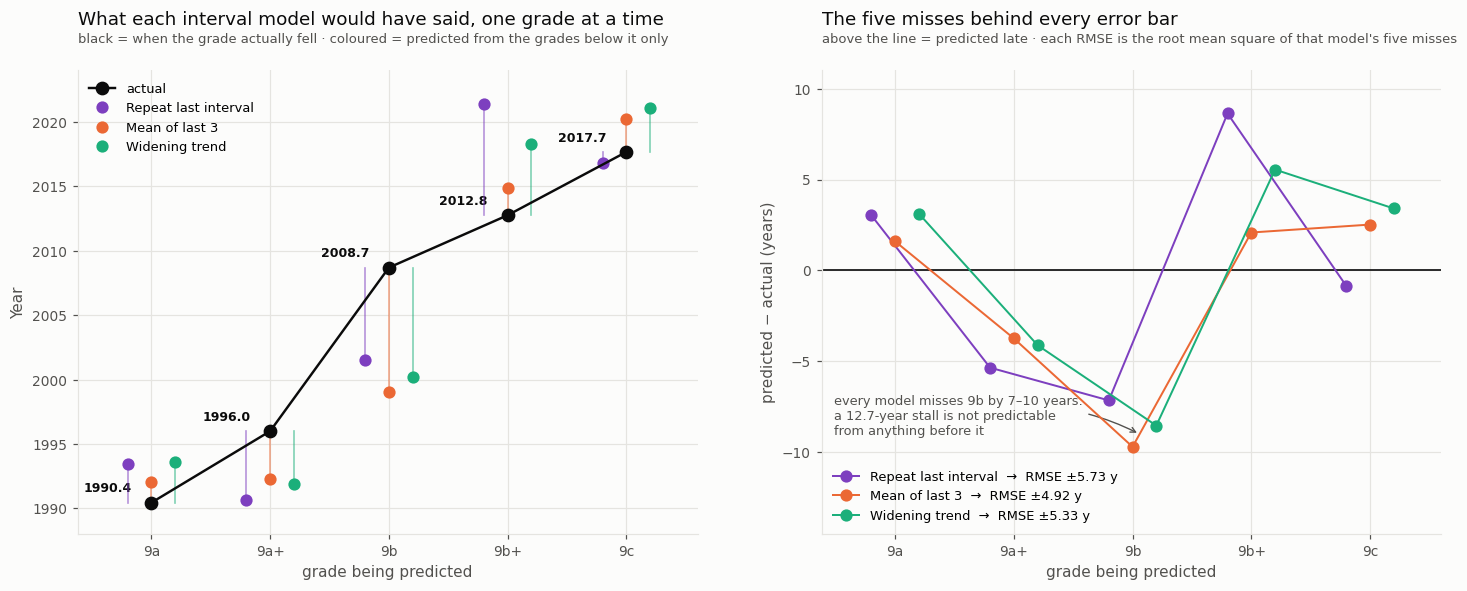

In [18]:
from matplotlib.lines import Line2D

GRADES = con["grade"].tolist()
FOLDS = list(range(5, NV))                 # 9a, 9a+, 9b, 9b+, 9c
BT = {"Repeat last interval": "#7d3fbf",
      "Mean of last 3": "#eb6834",
      "Widening trend": "#1baf7a"}

rows_bt = []
for name in INTERVALS:
    for j in FOLDS:
        pred = trained_on_first(name, j, GV[j])
        rows_bt.append({"method": name, "grade": GRADES[j],
                        "trained on": f"8a+..{GRADES[j - 1]}",
                        "predicted": pred, "actual": YV[j],
                        "error": pred - YV[j]})
bt = pd.DataFrame(rows_bt)
print(bt.round(2).to_string(index=False), end="\n\n")

RMSE_BT = {}
for name in INTERVALS:
    e = bt[bt["method"] == name]["error"].to_numpy()
    RMSE_BT[name] = float(np.sqrt(np.mean(e ** 2)))
    print(f"{name:<22} errors {np.round(e, 1)}  ->  RMSE {RMSE_BT[name]:.2f}")

xs = np.arange(len(FOLDS))
labels_bt = [GRADES[j] for j in FOLDS]
OFF = {"Repeat last interval": -.2, "Mean of last 3": 0.0, "Widening trend": .2}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.4, 6.2), dpi=110,
                               facecolor=PAPER)
fig.subplots_adjust(left=.06, right=.985, top=.80, bottom=.12, wspace=.20)
for ax in (axL, axR):
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

# --- left: what each model said, against what happened ---
axL.plot(xs, YV[5:], "-o", color=INK, lw=1.6, ms=8, zorder=5)
for k, j in enumerate(FOLDS):              # actual year, left of its dot
    axL.annotate(f"{YV[j]:.1f}", (xs[k], YV[j]), xytext=(-13, 7),
                 textcoords="offset points", ha="right", fontsize=8.2,
                 color=INK, fontweight="bold")
for name, color in BT.items():
    px = xs + OFF[name]
    py = [trained_on_first(name, j, GV[j]) for j in FOLDS]
    for k in range(len(xs)):               # the miss itself, drawn as a stem
        axL.plot([px[k], px[k]], [py[k], YV[5 + k]], color=color, lw=1.1,
                 alpha=.55, zorder=3)
    axL.plot(px, py, "o", color=color, ms=7, zorder=4)
axL.set_xticks(xs)
axL.set_xticklabels(labels_bt)
axL.set_xlim(-.62, len(xs) - .4)
axL.set_ylim(1988, 2024)
axL.set_xlabel("grade being predicted", color=MUTED)
axL.set_ylabel("Year", color=MUTED)
axL.set_title("What each interval model would have said, one grade at a time",
              color=INK, fontsize=12, loc="left", pad=30)
axL.text(0, 1.06, "black = when the grade actually fell · coloured = predicted "
                  "from the grades below it only",
         transform=axL.transAxes, fontsize=8.6, color=MUTED)
axL.legend(handles=[Line2D([], [], color=INK, marker="o", lw=1.6, ms=8,
                           label="actual")]
                   + [Line2D([], [], color=c, marker="o", lw=0, ms=7, label=n)
                      for n, c in BT.items()],
           frameon=False, fontsize=8.5, loc="upper left")

# --- right: the five misses that make each RMSE ---
axR.axhline(0, color=INK, lw=1.1, zorder=2)
for name, color in BT.items():
    e = [trained_on_first(name, j, GV[j]) - YV[j] for j in FOLDS]
    axR.plot(xs + OFF[name], e, "o-", color=color, lw=1.3, ms=7, zorder=4)
axR.set_xticks(xs)
axR.set_xticklabels(labels_bt)
axR.set_xlim(-.62, len(xs) - .4)
axR.set_ylim(-14.5, 11)
axR.set_xlabel("grade being predicted", color=MUTED)
axR.set_ylabel("predicted − actual (years)", color=MUTED)
axR.set_title("The five misses behind every error bar", color=INK, fontsize=12,
              loc="left", pad=30)
axR.text(0, 1.06, "above the line = predicted late · each RMSE is the root mean "
                  "square of that model's five misses",
         transform=axR.transAxes, fontsize=8.6, color=MUTED)
axR.legend(handles=[Line2D([], [], color=c, marker="o", lw=1.3, ms=7,
                           label=f"{n}  →  RMSE ±{RMSE_BT[n]:.2f} y")
                    for n, c in BT.items()],
           frameon=False, fontsize=8.5, loc="lower left")
axR.annotate("every model misses 9b by 7–10 years:\na 12.7-year stall is not "
             "predictable\nfrom anything before it",
             (2.06, -9.0), xytext=(.02, .30), textcoords="axes fraction",
             fontsize=8.4, color=MUTED, va="top",
             arrowprops=dict(arrowstyle="->", color=MUTED, lw=.9,
                             connectionstyle="arc3,rad=-.2"))
plt.show()

**The 9b column is most of every error bar.** All three models put 9b between
1999.0 and 2001.6. It fell in 2008.7. Nothing in the ladder before 1996 hinted
at a 12.7-year stall, so all three walked into it together — which is also why
averaging them bought nothing. They were wrong in the same direction at the same
moment.

**Then they overcorrect.** Repeat-last swallows that stall as its "last gap" and
puts 9b+ in 2021.4, 8.6 years late: the largest single miss in the set, arriving
immediately after its second-largest. Mean-of-3 and widening-trend spread the
stall across several gaps and overshoot by 2.1 and 5.7 years instead. Mean-of-3
does not win because it foresaw anything — it wins because it reacts to a shock
more gently.

**What that means for the ±4.9 on 9c+.** The band is built from four ordinary
steps and one regime change that every model got wrong, so it is honest about
ordinary steps and close to silent about regime changes. If the sport has been
in a new regime since 2017 — which the current nine-year stall might be — the
error bar is measuring the wrong thing, from five observations. Read it as *how
wrong this method has been before*, not as a probability.

One detail the left panel makes visible: **these models are never badly wrong
about a grade that follows an ordinary gap.** The 9c prediction is within 0.9
years for repeat-last and 2.5 for mean-of-3, and 9a is inside 3.6 for all three.
Every large miss in the chart is attached to the one stall and the correction
after it.

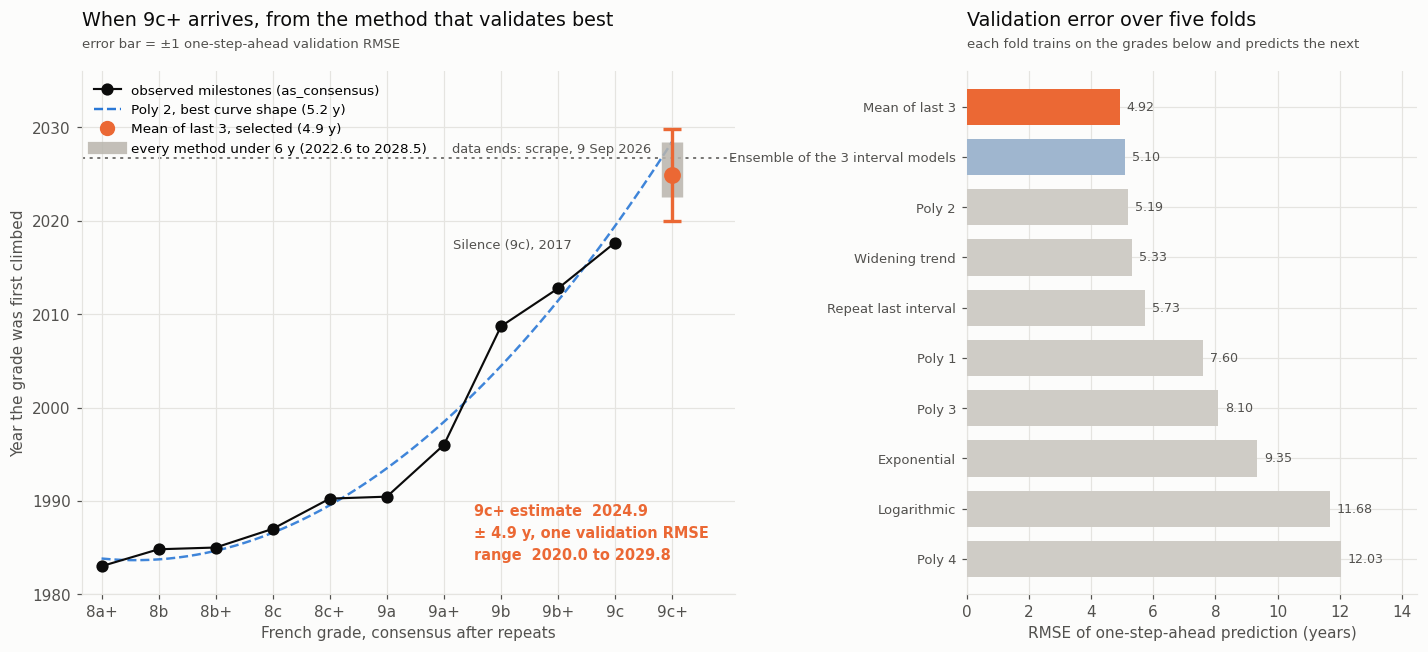

In [19]:
from matplotlib.lines import Line2D

SCRAPE = 2026 + (252 - 1) / 365.25         # the scrape date, 9 Sep 2026
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#b9b5ad"
best_name = BEST["method"]
best_9cp = float(BEST["9c+"])
best_rmse = float(BEST["RMSE (y)"])
best_lo, best_hi = best_9cp - best_rmse, best_9cp + best_rmse
spread = ROLL[ROLL["RMSE (y)"] <= 6.0]["9c+"].to_numpy(float)

fig = plt.figure(figsize=(13.2, 6.6), dpi=110, facecolor=PAPER)
grid = fig.add_gridspec(1, 2, width_ratios=[1.45, 1], wspace=.42,
                        left=.065, right=.985, top=.83, bottom=.11)
axL = fig.add_subplot(grid[0, 0])
axR = fig.add_subplot(grid[0, 1])
for ax in (axL, axR):
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

# --- left: the ladder, and where 9c+ lands ---
gg = np.linspace(0, 10, 300)
axL.plot(gg, [fit_on("Poly 2", GV, MV, YV, g) for g in gg], "--", color=BLUE,
         lw=1.6, alpha=.9, zorder=2)
axL.plot(GV, YV, "-o", color=INK, lw=1.4, ms=7, zorder=5)
axL.axhline(SCRAPE, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
axL.text(6.15, SCRAPE + .6, "data ends: scrape, 9 Sep 2026", fontsize=8.5,
         color=MUTED, ha="left")
axL.vlines(10, spread.min(), spread.max(), color=GREY, lw=14, alpha=.85, zorder=3)
axL.errorbar([10], [best_9cp], yerr=[best_rmse], fmt="o", color=ORANGE, ms=10,
             elinewidth=2.2, capsize=6, capthick=2.2, zorder=6)
axL.annotate("Silence (9c), 2017", (9, YV[-1]), xytext=(-106, -4),
             textcoords="offset points", fontsize=8.5, color=MUTED)
axL.text(.60, .06,
         f"9c+ estimate  {best_9cp:.1f}\n"
         f"± {best_rmse:.1f} y, one validation RMSE\n"
         f"range  {best_lo:.1f} to {best_hi:.1f}",
         transform=axL.transAxes, fontsize=9.5, color=ORANGE,
         fontweight="bold", va="bottom", linespacing=1.6)

handles = [
    Line2D([], [], color=INK, marker="o", lw=1.4, ms=7,
           label="observed milestones (as_consensus)"),
    Line2D([], [], color=BLUE, ls="--", lw=1.6,
           label="Poly 2, best curve shape (5.2 y)"),
    Line2D([], [], color=ORANGE, marker="o", lw=0, ms=9,
           label=f"{best_name}, selected (4.9 y)"),
    Line2D([], [], color=GREY, lw=8, alpha=.85,
           label=f"every method under 6 y ({spread.min():.1f} to {spread.max():.1f})"),
]
axL.legend(handles=handles, frameon=False, fontsize=8.8, loc="upper left")
axL.set_xticks(range(11))
axL.set_xticklabels(LADDER)
axL.set_xlim(-0.35, 11.1)
axL.set_ylim(1980, 2036)
axL.set_xlabel("French grade, consensus after repeats", color=MUTED)
axL.set_ylabel("Year the grade was first climbed", color=MUTED)
axL.set_title("When 9c+ arrives, from the method that validates best",
              color=INK, fontsize=12.5, loc="left", pad=30)
axL.text(0, 1.045, "error bar = ±1 one-step-ahead validation RMSE",
         transform=axL.transAxes, fontsize=8.7, color=MUTED)

# --- right: why that method was chosen ---
order = ROLL.sort_values("RMSE (y)", ascending=False)
cols = [ORANGE if m == best_name else ("#9fb6cf" if "Ensemble" in m else "#cfccc6")
        for m in order["method"]]
axR.barh(range(len(order)), order["RMSE (y)"], color=cols, zorder=3, height=.72)
axR.set_yticks(range(len(order)))
axR.set_yticklabels(order["method"], fontsize=8.6, color=MUTED)
for i, v in enumerate(order["RMSE (y)"]):
    axR.text(v + .22, i, f"{v:.2f}", va="center", fontsize=8.3, color=MUTED)
axR.set_xlim(0, 14.5)
axR.set_ylim(-.7, len(order) - .3)
axR.set_xlabel("RMSE of one-step-ahead prediction (years)", color=MUTED)
axR.set_title("Validation error over five folds", color=INK, fontsize=12.5,
              loc="left", pad=30)
axR.text(0, 1.045, "each fold trains on the grades below and predicts the next",
         transform=axR.transAxes, fontsize=8.7, color=MUTED)

plt.show()

**9c+ in 2024.9, give or take about five years — and that date is already in
the past.**

The method that survives the test is the *average of the last three gaps*: take
how long the last three grades took (12.7, 4.1 and 4.9 years), average them
(7.2), and add that to Silence. It assumes nothing at all about the ladder's
shape, and it beats every curve fitted to the same data.

| | 9c+ | typical miss |
| --- | --- | --- |
| **Average of the last 3 gaps** (selected) | **2024.9** | **4.9 y** |
| Blend of the three interval models | 2024.3 | 5.1 y |
| Poly 2 (best curve) | 2028.5 | 5.2 y |
| Widening trend | 2025.5 | 5.3 y |
| Repeat the last gap | 2022.6 | 5.7 y |
| Poly 4 (winner of the single test) | 2016.4 | 12.0 y |

Every method with a typical miss under six years lands between **2022.6 and
2028.5** — the grey bar on the chart — and that range is a better-supported
claim than any single date inside it. The scrape date, 9 Sep 2026, sits in the
middle of it.

So the notebook's earlier verdict survives in a sharper form. **9c+ is not
overdue by a decade; it is overdue by about two years, and it should arrive
before 2030 if the sport keeps behaving as it has since 1990.** The failure mode
to watch is the one the tests already exposed: every method missed 9b low by 7
to 15 years, so a single long stall is exactly the event none of them can
anticipate. The current stall is nine years old and, by the interval analysis
above, does not become the longest on record until 2030.

### Each method on its own panel, two grades out

The chart above puts one estimate on the ladder. This puts all five methods that
scored under six years side by side, one panel each, and pushes every one of
them **two** steps past Silence: to 9c+, and then to **10a**, the grade after
that.

Two things are drawn differently on purpose. **Poly 2 is a curve through all ten
milestones**, so it is drawn across the whole ladder — its prediction is wherever
that curve happens to cross 9c+ and 10a. **The interval models are not curves.**
They know only the gaps between consecutive grades and step forward from
Silence, so they are drawn as a projection from 9c with nothing behind it.
Drawing them the same way would misrepresent what they do.

The second step is weaker evidence than the first, and is marked as such: the
bar at 9c+ is the track record from the tests above, and the 10a marker is
hollow because **nothing here validates a two-step jump.** Every test predicted
exactly one grade ahead. Read 10a as an illustration of how fast the
disagreement grows once you leave the data, not as a forecast.

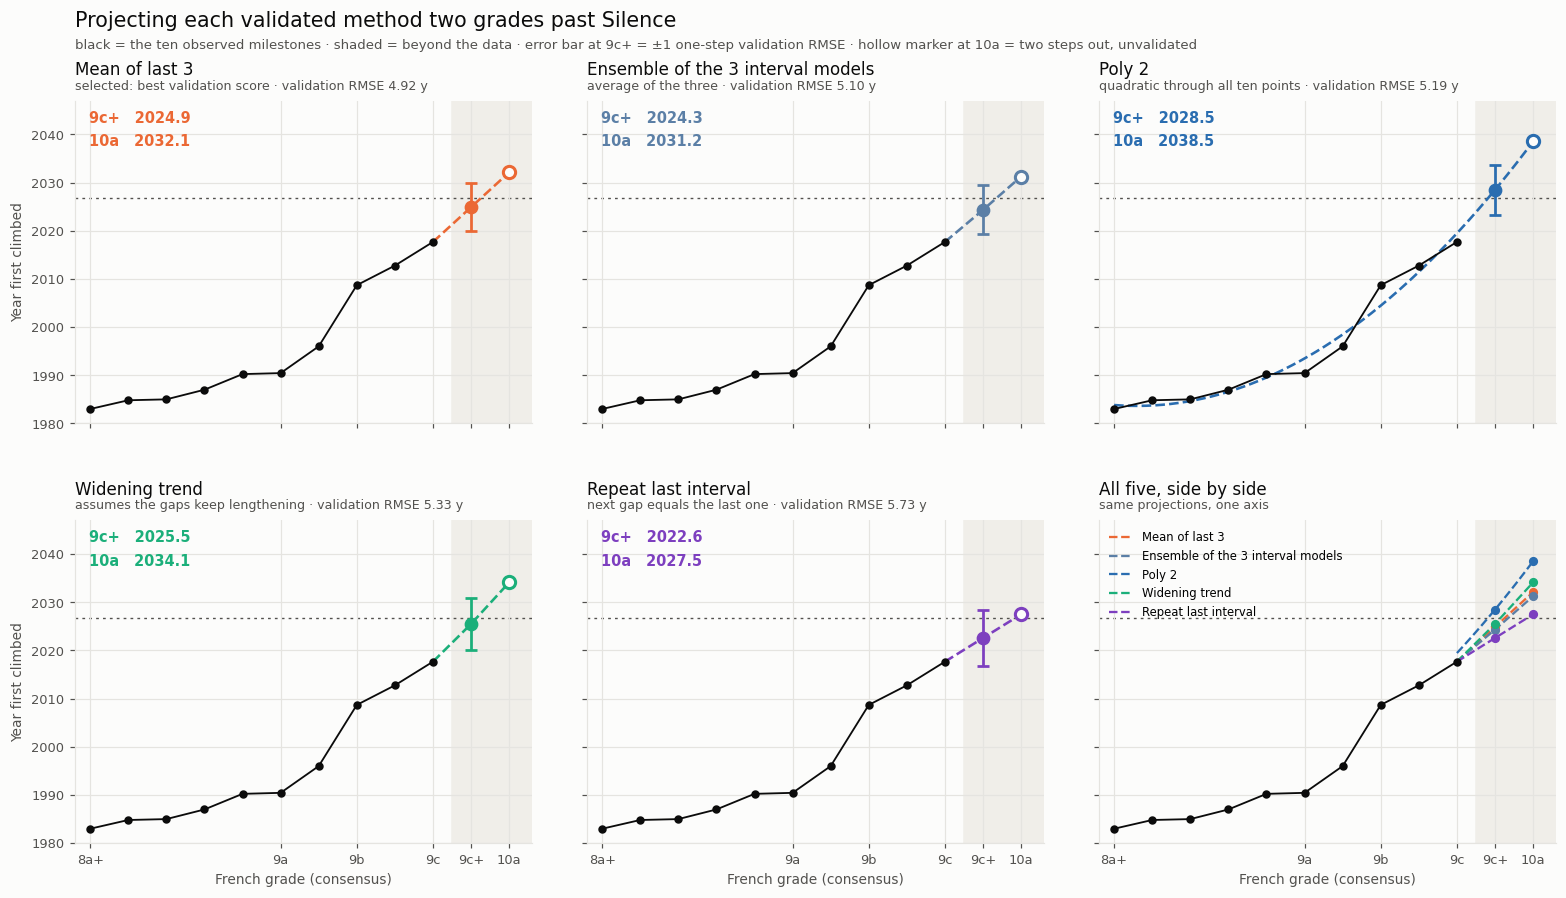

                           method  RMSE (y)     9c+     10a  implied gap
                   Mean of last 3      4.92 2024.89 2032.12         7.22
Ensemble of the 3 interval models      5.10 2024.33 2031.25         6.92
                           Poly 2      5.19 2028.48 2038.52        10.04
                   Widening trend      5.33 2025.50 2034.13         8.62
             Repeat last interval      5.73 2022.58 2027.50         4.91


In [20]:
# predicted date at `target` steps, fitted on all ten milestones
def project(name, target):
    if name == "Ensemble of the 3 interval models":
        return float(np.mean([fit_on(m, GV, MV, YV, target) for m in INTERVALS]))
    return fit_on(name, GV, MV, YV, target)


# Ordered by the validation score above. The scores are looked up from ROLL
# rather than retyped, so these panels and the table that scores them cannot
# drift apart when the underlying ladder changes.
SCORE = ROLL.set_index("method")["RMSE (y)"]
PANELS = [
    ("Mean of last 3", "#eb6834", "selected: best validation score"),
    ("Ensemble of the 3 interval models", "#5b7fa6", "average of the three"),
    ("Poly 2", "#2a6db0", "quadratic through all ten points"),
    ("Widening trend", "#1baf7a", "assumes the gaps keep lengthening"),
    ("Repeat last interval", "#7d3fbf", "next gap equals the last one"),
]
PANELS = [(n, float(SCORE[n]), c, b) for n, c, b in PANELS]
TICKS = [0, 5, 7, 9, 10, 11]
TICKLAB = ["8a+", "9a", "9b", "9c", "9c+", "10a"]
YLO, YHI = 1980, 2047

fig, axes = plt.subplots(2, 3, figsize=(14.4, 8.6), dpi=110, facecolor=PAPER,
                         sharex=True, sharey=True)
fig.subplots_adjust(left=.055, right=.99, top=.87, bottom=.085,
                    wspace=.12, hspace=.30)
for ax in axes.ravel():
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=8.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

for ax, (name, rmse, color, blurb) in zip(axes.ravel(), PANELS):
    ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)       # beyond the data
    ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
    ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)

    p10, p11 = project(name, 10.0), project(name, 11.0)
    if name == "Poly 2":                                   # a curve through the data
        gg = np.linspace(0, 11, 260)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.7,
                zorder=3)
    else:                                                  # a forward projection only
        ax.plot([9, 10, 11], [YV[-1], p10, p11], "--", color=color, lw=1.7,
                zorder=3)
    ax.errorbar([10], [p10], yerr=[rmse], fmt="o", color=color, ms=8,
                elinewidth=1.8, capsize=4, capthick=1.8, zorder=6)
    ax.plot([11], [p11], "o", mfc=PAPER, mec=color, mew=2, ms=8, zorder=6)

    # the ladder rises steeply under both markers, so the dates go in the
    # panel corner rather than beside the points they belong to
    ax.text(.03, .97, f"9c+   {p10:.1f}\n10a   {p11:.1f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9.5,
            color=color, fontweight="bold", linespacing=1.7)
    ax.set_title(name, color=INK, fontsize=11, loc="left", pad=17)
    ax.text(0, 1.035, f"{blurb} · validation RMSE {rmse:.2f} y",
            transform=ax.transAxes, fontsize=8.3, color=MUTED)

ax = axes.ravel()[5]                                       # all five together
ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)
ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)
for name, rmse, color, _ in PANELS:
    p10, p11 = project(name, 10.0), project(name, 11.0)
    if name == "Poly 2":
        gg = np.linspace(9, 11, 60)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.5,
                zorder=3)
    else:
        ax.plot([9, 10, 11], [YV[-1], p10, p11], "--", color=color, lw=1.5,
                zorder=3)
    ax.plot([10, 11], [p10, p11], "o", color=color, ms=5, zorder=5)
ax.set_title("All five, side by side", color=INK, fontsize=11, loc="left", pad=17)
ax.text(0, 1.035, "same projections, one axis", transform=ax.transAxes,
        fontsize=8.3, color=MUTED)
ax.legend(handles=[Line2D([], [], color=c, ls="--", lw=1.5, label=n)
                   for n, _, c, _ in PANELS],
          frameon=False, fontsize=7.6, loc="upper left")

for ax in axes.ravel():
    ax.set_xticks(TICKS)
    ax.set_xticklabels(TICKLAB)
    ax.set_xlim(-0.4, 11.6)
    ax.set_ylim(YLO, YHI)
for ax in axes[1]:
    ax.set_xlabel("French grade (consensus)", color=MUTED, fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("Year first climbed", color=MUTED, fontsize=9)

fig.suptitle("Projecting each validated method two grades past Silence",
             color=INK, fontsize=13.5, x=.055, ha="left", y=.965)
fig.text(.055, .925,
         "black = the ten observed milestones · shaded = beyond the data · "
         "error bar at 9c+ = ±1 one-step validation RMSE · "
         "hollow marker at 10a = two steps out, unvalidated",
         fontsize=8.7, color=MUTED)
plt.show()

print(pd.DataFrame([{"method": n, "RMSE (y)": r,
                     "9c+": project(n, 10.0), "10a": project(n, 11.0),
                     "implied gap": project(n, 11.0) - project(n, 10.0)}
                    for n, r, _, _ in PANELS]).round(2).to_string(index=False))

| | 9c+ | 10a | implied gap |
| --- | --- | --- | --- |
| **Average of the last 3 gaps** (selected) | **2024.9** | **2032.1** | 7.2 y |
| Blend of the three interval models | 2024.3 | 2031.3 | 6.9 y |
| Poly 2 (best curve) | 2028.5 | 2038.5 | 10.0 y |
| Widening trend | 2025.5 | 2034.1 | 8.6 y |
| Repeat the last gap | 2022.6 | 2027.5 | 4.9 y |

**The five agree on 9c+ within six years and disagree about 10a by eleven.**
That widening is the whole reason to plot the second step: 2022.6–2028.5 becomes
2027.5–2038.5, because each method's assumption about the *next* gap compounds
when it is applied twice. Repeat-last keeps spending 4.9 years a grade and stays
earliest; poly 2's curve keeps steepening, so its second step costs a full
decade; the other two sit between, adding about seven years each.

Two cautions the panels encode rather than state. **Only the 9c+ step was
tested** — every fold predicted one grade ahead, so the hollow 10a markers carry
no error bar the data has earned. A two-step miss is certainly worse than the
one-step 4.9–5.7 years shown, but this dataset cannot say by how much. And
**10a is a grade nobody has proposed**, so its "prediction" is a statement about
the ladder's rhythm continuing, not about any route or climber. Silence still
has no repeat, and the sport has never confirmed two consecutive grades as
quickly as these projections require.

The one claim the panels support jointly: **every method that survived the test
puts 9c+ before 2030, and none puts 10a before 2027.**

### The same panels, for the curves instead

The figure above gives a panel to each method that scored under six years, and
four of those five are interval arithmetic. This is the counterpart for the
**fitted curves**: the five best-scoring shapes, ranked by the same test,
projected to 9c+ and 10a on the same axes.

Of the six shapes, **Poly 4 is the one dropped**, and it earned that twice over:
the worst score of the six (12.0 years), and it is the only shape here that runs
backwards once past the data. It turns around at step **9.34** — before 9c+ is
even reached — and dates 10a (2005.1) **eleven years before** its own 9c+
(2016.4). That is the polynomial failure this notebook flags at "shown only to
be distrusted", happening inside the range being asked about rather than safely
outside it.

Every curve is drawn across the whole ladder, because unlike the interval models
each one is fitted through all ten milestones. The markers keep their meaning
from the previous figure: filled at 9c+ with the track-record bar, hollow at 10a
because nothing validates a two-step jump.

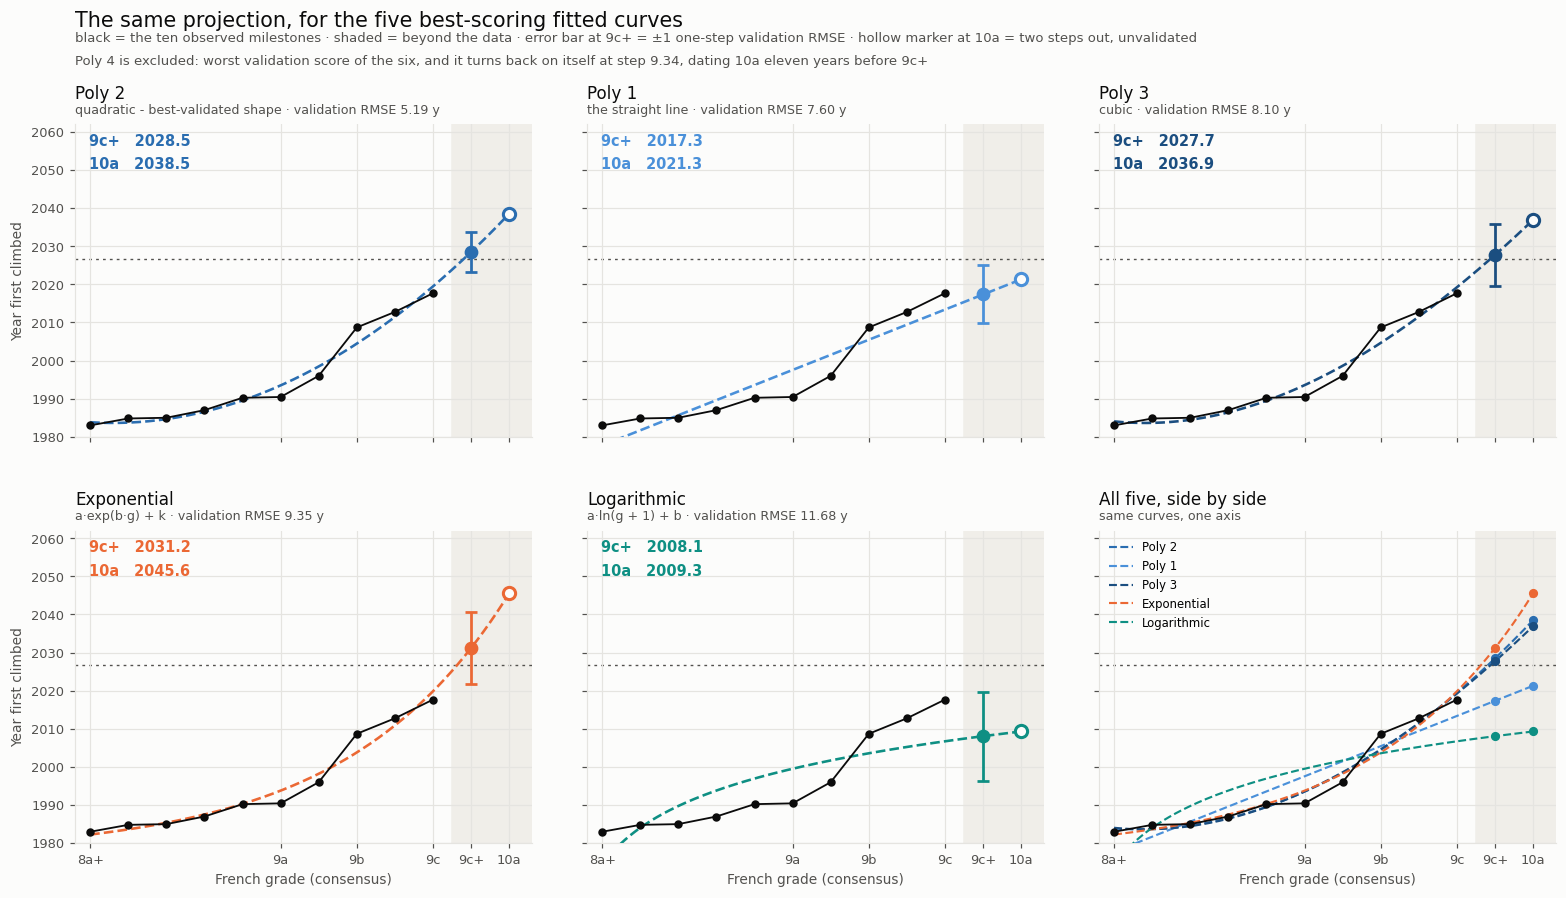

      shape  RMSE (y)     9c+     10a  implied gap
     Poly 2      5.19 2028.48 2038.52        10.04
     Poly 1      7.60 2017.34 2021.30         3.96
     Poly 3      8.10 2027.72 2036.92         9.20
Exponential      9.35 2031.20 2045.56        14.36
Logarithmic     11.68 2008.08 2009.30         1.23


In [21]:
# Five best-scoring shapes, by validation RMSE; scores read from ROLL so they
# cannot drift from the table that produced them.
FN = [
    ("Poly 2", "#2a6db0", "quadratic - best-validated shape"),
    ("Poly 1", "#4a90d9", "the straight line"),
    ("Poly 3", "#1b4e80", "cubic"),
    ("Exponential", "#eb6834", "a·exp(b·g) + k"),
    ("Logarithmic", "#0e8f83", "a·ln(g + 1) + b"),
]
FN = [(n, float(ROLL.set_index("method").loc[n, "RMSE (y)"]), c, b)
      for n, c, b in FN]
YLO, YHI = 1980, 2062            # Exponential reaches 2045 at 10a, plus its bar

fig, axes = plt.subplots(2, 3, figsize=(14.4, 8.6), dpi=110, facecolor=PAPER,
                         sharex=True, sharey=True)
fig.subplots_adjust(left=.055, right=.99, top=.845, bottom=.085,
                    wspace=.12, hspace=.30)
for ax in axes.ravel():
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=8.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

gg = np.linspace(0, 11, 260)
for ax, (name, rmse, color, blurb) in zip(axes.ravel(), FN):
    ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)       # beyond the data
    ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
    ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)

    p10, p11 = project(name, 10.0), project(name, 11.0)
    ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.7,
            zorder=3)
    ax.errorbar([10], [p10], yerr=[rmse], fmt="o", color=color, ms=8,
                elinewidth=1.8, capsize=4, capthick=1.8, zorder=6)
    ax.plot([11], [p11], "o", mfc=PAPER, mec=color, mew=2, ms=8, zorder=6)

    ax.text(.03, .97, f"9c+   {p10:.1f}\n10a   {p11:.1f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9.5,
            color=color, fontweight="bold", linespacing=1.7)
    ax.set_title(name, color=INK, fontsize=11, loc="left", pad=17)
    ax.text(0, 1.035, f"{blurb} · validation RMSE {rmse:.2f} y",
            transform=ax.transAxes, fontsize=8.3, color=MUTED)

ax = axes.ravel()[5]                                       # all five together
ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)
ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)
for name, rmse, color, _ in FN:
    ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.4,
            zorder=3)
    ax.plot([10, 11], [project(name, 10.0), project(name, 11.0)], "o",
            color=color, ms=5, zorder=5)
ax.set_title("All five, side by side", color=INK, fontsize=11, loc="left", pad=17)
ax.text(0, 1.035, "same curves, one axis", transform=ax.transAxes,
        fontsize=8.3, color=MUTED)
ax.legend(handles=[Line2D([], [], color=c, ls="--", lw=1.4, label=n)
                   for n, _, c, _ in FN],
          frameon=False, fontsize=7.6, loc="upper left")

for ax in axes.ravel():
    ax.set_xticks(TICKS)
    ax.set_xticklabels(TICKLAB)
    ax.set_xlim(-0.4, 11.6)
    ax.set_ylim(YLO, YHI)
for ax in axes[1]:
    ax.set_xlabel("French grade (consensus)", color=MUTED, fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("Year first climbed", color=MUTED, fontsize=9)

fig.suptitle("The same projection, for the five best-scoring fitted curves",
             color=INK, fontsize=13.5, x=.055, ha="left", y=.965)
fig.text(.055, .932,
         "black = the ten observed milestones · shaded = beyond the data · "
         "error bar at 9c+ = ±1 one-step validation RMSE · "
         "hollow marker at 10a = two steps out, unvalidated",
         fontsize=8.7, color=MUTED)
fig.text(.055, .908,
         "Poly 4 is excluded: worst validation score of the six, and it turns "
         "back on itself at step 9.34, dating 10a eleven years before 9c+",
         fontsize=8.7, color=MUTED)
plt.show()

print(pd.DataFrame([{"shape": n, "RMSE (y)": r,
                     "9c+": project(n, 10.0), "10a": project(n, 11.0),
                     "implied gap": project(n, 11.0) - project(n, 10.0)}
                    for n, r, _, _ in FN]).round(2).to_string(index=False))

| | 9c+ | 10a | implied gap | typical miss |
| --- | --- | --- | --- | --- |
| Poly 2 | 2028.5 | 2038.5 | 10.0 y | 5.2 y |
| Poly 1 | 2017.3 | 2021.3 | 4.0 y | 7.6 y |
| Poly 3 | 2027.7 | 2036.9 | 9.2 y | 8.1 y |
| Exponential | 2031.2 | 2045.6 | 14.4 y | 9.4 y |
| Logarithmic | 2008.1 | 2009.3 | 1.2 y | 11.7 y |

**Beside the interval models, the curves are both further apart and worse.**
Those five put 9c+ between 2022.6 and 2028.5, a six-year span, with typical
misses of 4.9 to 5.7 years. These five span **2008.1 to 2031.2** — twenty-three
years, two of them already past — with typical misses of 5.2 to 11.7. Only one
curve, the quadratic, scores in the same class as the arithmetic.

**The disagreement is about shape, and it compounds at 10a.** The implied gap
from 9c+ to 10a runs from 1.2 years (the logarithm, flattening towards a ceiling
it never reaches) to 14.4 (the exponential, accelerating away from the data).
Neither is a claim about climbing; both are just what the formula does when you
keep going. The interval models cannot disagree by more than the gaps
themselves, which is exactly why they score better.

Read the curve panel as **2027–2031**, from the three shapes that can bend
upward, against the interval models' **2022–2029**. They overlap, and both
straddle 2026.